# Lab: Machine Learning Pipelines and GridSearchCV

---

In this lab, we'll learn how to:
* Build an evaluate a machine learning pipeline
* Implement GridSearchCV for hyperparameter tuning with cross-validation
* Implement and optimize a complex classification pipeline using real-world data
* Extract feature importances from a trained pipeline

---

## 1. Introduction
**Pipelines** are a crucial tool in Scikit-learn that combine preprocessing and modeling into a single, reproducible workflow.

**Key Points:**  
* **Structure:** A sequence of transformers (fit + transform) followed by an optional final estimator (fit only)
* **Consistency:** Ensures the same transformations applied during training are applied to new data during prediction.
* **Parameter Tuning:** Use double unserscores (`__`) to set parameters on pipeline steps, e.g., `imputer__strategy='median'`
* **Flexibility:** Steps can be swapped, bypassed with `passthrough`, or set to `None`
* **GridSearchCV Integration:** Pipelines enable simultaneous hyperparameter tuning of *all* steps (preprocessing + model), not just the model alone.
* **Reproducibility:** Essential for preventing data leakage and ensuring consistent preprocessing across train/test/production data.

> ⚠️ **Note on Application:** During development in Jupyter notebooks, we do experiment freely. However, when deploying, wrapping everything in a Pipeline with GridSearchCV ensures that our preprocessing and model hyperparameters are optimally tuned together and will behave identically in production.

---

### Project Roadmap
In this lab, we will:
* Generate synthetic data for running targeted experiments using scikit-learn
* Train and evaluate a KNN classification model using a pipeline
* Tune model hyperparameters using a pipeline within a cross-validation grid search
* Build a more complex random forest classification pipeline using real-world data
* Extract the feature importances from the trained pipeline

Let's start with importing the require libraries.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

For starters, let's build a pipeline, fitting it  to the Iris data, and evaluating its accuracy. First we'll load the data.

In [7]:
data = load_iris()
X, y = data.data, data.target
labels = data.target_names

Now we'll instantiate a Pipeline consisting of StandardScaler, PCA, and KNeighborsClassifier. For this, we need to pass the steps as tuples where the first element is the name of the step and the second element is the instantiated transformer or estimator.

In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Step 1: Standardize the features
    ('pca', PCA(n_components=2)), # Step 2: Reduce dimensions to 2 using PCA
    ('knn', KNeighborsClassifier(n_neighbors=5)) # Step 3: K-Nearest Neighbors classifier
])

It's time to split the data into training and test sets. We'll make sure to stratify the target.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Now it's time to fit the pipeline on the training set and evaluate its accuracy.

Our pipeline consists of a sequence of three estimators, and should be viewed as the machine learning model we are training and testing.

In [12]:
pipeline.fit(X_train, y_train)

# .score() returns the default score for the estimator, which is accuracy for classifiers such as KNeighborsClassifier
test_score = pipeline.score(X_test, y_test) 
print(f"Test set accuracy: {test_score:.3f}")

Test set accuracy: 0.900


Now it's time to get the model predictions, generate the confusion matrix for the KNN model and plot it.

In [13]:
y_pred = pipeline.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

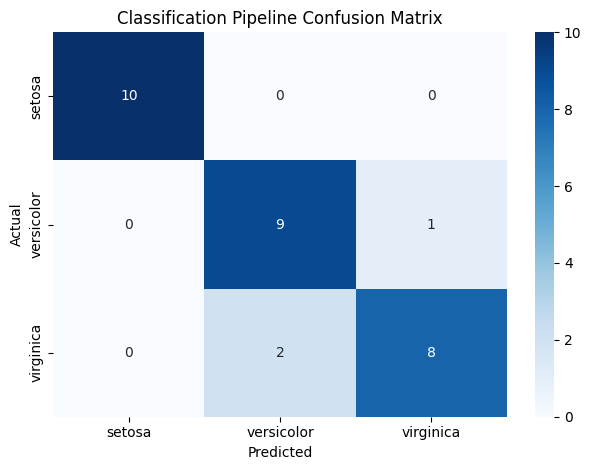

In [14]:
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Classification Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

* 📌 The model incorrectly classified two virginica irises as versicolor, and one versicolor as virginica. Only three classification errors out of 30 on our first attempt is not bad!

Now it's time to optimize our model. Remember that it would be a mistake to keep running the model over and over again with different hyperparameters to find the best one. This would cause overfitting. The correct way to handle this tuning is to use cross validation.

For this, we initiate another pipeline, but without specifying any hyperparameters. We will let GridSearchCV handle that.

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Step 1: Standardize the features
    ('pca', PCA()), # Step 2: Reduce dimensions using PCA
    ('knn', KNeighborsClassifier()) # Step 3: K-Nearest Neighbors classifier
])

Let's create the hyperparameter grid to search over. We will tune the number of PCA components as well as the number of neighbors in the KNN classifier.

In [17]:
param_grid = {
    'pca__n_components': [2, 3],
    'knn__n_neighbors': [3, 5, 7]
}

To ensure the target is stratified, we can use scikit-learn's `StratifiedKFold` cross-validation class.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In order to determine the best hyperparameters, we will pass our `pipeline`, `param_grid`, and `cv` to `GridSearchCV`.

In [20]:
best_model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2 # To show progress messages
)

Now we fit the `best_model` on the training data.

In [21]:
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'pca__n_components': [2, 3]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


When we explore the `GridSearchCV` object, we can see the best hyperparameters found during the search. We can also print these hyperparameters in a more readable format.

In [22]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}